# CNN Training on STFT and CWT Image Representations (Chen2020 Architecture)

This notebook trains two convolutional neural networks using the Chen et al. (2020) 2D-CNN architecture, applied to the 256×256 RGB STFT and CWT images generated previously. The objective is to reproduce Chen’s baseline model in a fully reproducible pipeline and compare both time–frequency representations.

**1. Input dataset**  
We load the images stored in `Images_STFT_CWT/`, already organized into `train/` and `test/` folders for each class. All images are:
- RGB (3 channels)  
- 256×256  
- normalized to [-1, 1]  
- named as `segXXXXX_clsC_loadL.png`

Hidden Jupyter folders are removed to ensure clean class labels when using `ImageFolder`.

**2. CNN model (Chen2020)**  
We implement the exact architecture from Table 3 of Chen et al. (2020), adapted only to accept 3 input channels:
- Conv 9×9 stride 2 → ReLU  
- Conv 9×9 stride 2 → ReLU → MaxPool 4×4  
- Conv 4×4 stride 2 → ReLU  
- Conv 4×4 stride 2 → ReLU → MaxPool 2×2  
- FC layers: 128 → 32 → 4 logits  
The flatten size is computed using a dummy forward pass.

**3. Training procedure**  
For each representation (STFT and CWT), we run:
- optimizer: Adam  
- loss: CrossEntropyLoss  
- metrics per epoch: training/validation loss and accuracy  
- confusion matrix and classification report  
- saved training curves, metrics, and model weights under `model_training_results/`

**4. Outputs**  
This notebook produces two trained models (`CNN_STFT.pth` and `CNN_CWT.pth`) plus all training plots and classification metrics. These models are used directly in the next notebook for explainability (Grad-CAM, Grad-CAM++, RISE).



In [1]:
# ============================================================
# 1. Imports, SEED, device, paths, datasets
# ============================================================

import os
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
import shutil
import random

# ------------------------------------------------------------
# Reproducibility SEED 
# ------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Using global reproducibility SEED = {SEED}")

# ------------------ Device ------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ------------------ Paths -------------------
PROJECT_ROOT = Path.cwd()

# Organized data root (from Notebook 01)
DATA_ROOT = PROJECT_ROOT / "data_CWRU_Organized"

# Generated STFT & CWT images (from Notebook 03)
IMG_ROOT = PROJECT_ROOT / "Images_STFT_CWT"

# Output root for all training results
RESULTS_ROOT = PROJECT_ROOT / "model_training_results"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

# Subfolders
PLOTS_ROOT = RESULTS_ROOT / "plots"
MODELS_ROOT = RESULTS_ROOT / "models"
PLOTS_ROOT.mkdir(exist_ok=True)
MODELS_ROOT.mkdir(exist_ok=True)

CLASS_NAMES = ["Baseline", "Inner", "Outer", "Ball"]
num_classes = len(CLASS_NAMES)

# Common image transforms (normalize same as during training)
img_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

def make_loaders(rep_name, batch_size=32):
    """
    rep_name: 'STFT' or 'CWT'
    Returns train_loader, test_loader
    """
    train_dir = IMG_ROOT / rep_name / "train"
    test_dir  = IMG_ROOT / rep_name / "test"

    train_ds = datasets.ImageFolder(root=train_dir, transform=img_transforms)
    test_ds  = datasets.ImageFolder(root=test_dir,  transform=img_transforms)

    print(f"[{rep_name}] #train = {len(train_ds)}, #test = {len(test_ds)}")

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True, num_workers=0,
                              pin_memory=(device.type == "cuda"))
    test_loader  = DataLoader(test_ds, batch_size=batch_size,
                              shuffle=False, num_workers=0,
                              pin_memory=(device.type == "cuda"))
    return train_loader, test_loader

# ------------------------------------------------------------
# Clean unwanted Jupyter checkpoints
# ------------------------------------------------------------
def remove_hidden_folders(base_dir):
    """Remove .ipynb_checkpoints or hidden folders."""
    if not base_dir.exists():
        return
    for sub in base_dir.iterdir():
        if sub.is_dir() and sub.name.startswith("."):
            print(f"Removing hidden folder: {sub}")
            shutil.rmtree(sub)


Using global reproducibility SEED = 42
Using device: cuda


In [2]:
# ============================================================
# 2. Chen 2D-CNN model
# ============================================================
class Chen2DCNN(nn.Module):
    """
    Implementation of Table 3 from Chen2020 for 256x256 RGB inputs.

    Conv1: 9x9, stride 2, 4 filters, ReLU
    Conv2: 9x9, stride 2, 8 filters, ReLU
    Pool2: 4x4 max pool
    Conv3: 4x4, stride 2, 16 filters, ReLU
    Conv4: 4x4, stride 2, 32 filters, ReLU
    Pool4: 2x2 max pool
    FC1: 128 nodes, ReLU
    FC2: 32 nodes, ReLU
    Output: 4 nodes, Softmax (via CrossEntropyLoss)
    """

    def __init__(self, in_channels=3, num_classes=4):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 4, kernel_size=9, stride=2, padding=4)
        self.conv2 = nn.Conv2d(4, 8, kernel_size=9, stride=2, padding=4)
        self.pool2 = nn.MaxPool2d(kernel_size=4, stride=4)

        self.conv3 = nn.Conv2d(8, 16, kernel_size=4, stride=2, padding=2)
        self.conv4 = nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=2)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # determine flatten size with dummy forward
        with torch.no_grad():
            x = torch.zeros(1, in_channels, 256, 256)
            x = self.pool2(F.relu(self.conv2(F.relu(self.conv1(x)))))
            x = self.pool4(F.relu(self.conv4(F.relu(self.conv3(x)))))
            flat_dim = x.numel()

        self.fc1 = nn.Linear(flat_dim, 128)
        self.fc2 = nn.Linear(128, 32)
        self.out = nn.Linear(32, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool4(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

# quick sanity check
test_net = Chen2DCNN(in_channels=3, num_classes=num_classes).to(device)
dummy = torch.randn(2, 3, 256, 256).to(device)
out = test_net(dummy)
print("Model output shape:", out.shape)
print("Total params:", sum(p.numel() for p in test_net.parameters()))


Model output shape: torch.Size([2, 4])
Total params: 34636


In [3]:
# ============================================================
# 3. Training + evaluation utilities
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, epoch, num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    t0 = time()
    for batch_idx, (inputs, targets) in enumerate(loader, start=1):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(targets).sum().item()
        total += targets.size(0)

        # simple inline progress
        if batch_idx % 10 == 0 or batch_idx == len(loader):
            pct = 100.0 * batch_idx / len(loader)
            print(f"  [Epoch {epoch}/{num_epochs}] "
                  f"batch {batch_idx}/{len(loader)} ({pct:5.1f}%)",
                  end="\r")

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    t1 = time()
    print(f"  [Epoch {epoch}/{num_epochs}] "
          f"Train loss={epoch_loss:.4f}, acc={epoch_acc:.4f}, "
          f"time={t1-t0:.1f}s")
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_targets = []
    all_preds   = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(targets).sum().item()
            total += targets.size(0)

            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    return epoch_loss, epoch_acc, y_true, y_pred


def train_model_for_rep(rep_name,
                        num_epochs=30,
                        lr=1e-3,
                        in_channels=3,
                        batch_size=32):
    print(f"\n==================== {rep_name} TRAINING ====================\n")
    train_loader, test_loader = make_loaders(rep_name, batch_size=batch_size)

    model = Chen2DCNN(in_channels=in_channels, num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [],   "val_acc": []
    }

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer,
            epoch=epoch, num_epochs=num_epochs
        )
        val_loss, val_acc, y_true, y_pred = evaluate(model, test_loader, criterion)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"  --> Val   loss={val_loss:.4f}, acc={val_acc:.4f}")
        print("-" * 60)

    # ---- plots ----
    epochs = range(1, num_epochs + 1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], label="train")
    plt.plot(epochs, history["val_loss"],   label="val")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"{rep_name} loss"); plt.grid(); plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, history["train_acc"], label="train")
    plt.plot(epochs, history["val_acc"],   label="val")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title(f"{rep_name} accuracy"); plt.grid(); plt.legend()
    plt.tight_layout()
    plot_path = PLOTS_ROOT / f"{rep_name}_training_curves.png"
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    # ---- confusion matrix ----
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,
                cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{rep_name} – Confusion matrix")
    plt.tight_layout()
    cm_path = PLOTS_ROOT / f"{rep_name}_confusion_matrix.png"
    plt.savefig(cm_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"\n{rep_name} classification report:\n")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    np.savez(
    RESULTS_ROOT / f"{rep_name}_training_history.npz",
    train_loss=history["train_loss"],
    train_acc=history["train_acc"],
    val_loss=history["val_loss"],
    val_acc=history["val_acc"]
)
    return model, history



==================== STFT TRAINING ====================

[STFT] #train = 2051, #test = 879
  [Epoch 1/5] Train loss=0.7320, acc=0.6845, time=29.5s
  --> Val   loss=0.1470, acc=0.9238
------------------------------------------------------------
  [Epoch 2/5] Train loss=0.0907, acc=0.9590, time=4.3s
  --> Val   loss=0.0483, acc=0.9863
------------------------------------------------------------
  [Epoch 3/5] Train loss=0.0258, acc=0.9912, time=4.0s
  --> Val   loss=0.0024, acc=1.0000
------------------------------------------------------------
  [Epoch 4/5] Train loss=0.0017, acc=1.0000, time=4.0s
  --> Val   loss=0.0009, acc=1.0000
------------------------------------------------------------
  [Epoch 5/5] Train loss=0.0007, acc=1.0000, time=4.0s
  --> Val   loss=0.0003, acc=1.0000
------------------------------------------------------------


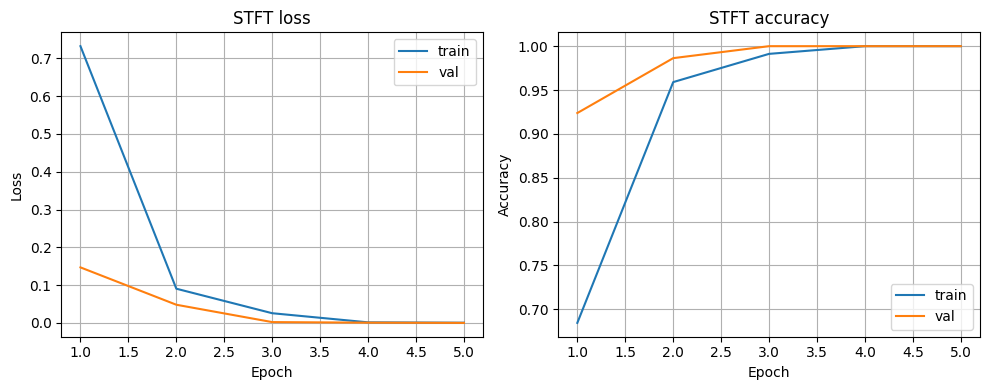

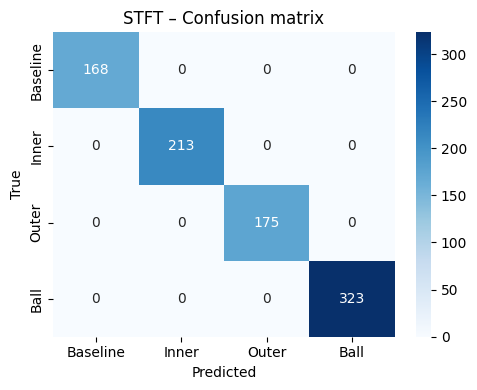


STFT classification report:

              precision    recall  f1-score   support

    Baseline       1.00      1.00      1.00       168
       Inner       1.00      1.00      1.00       213
       Outer       1.00      1.00      1.00       175
        Ball       1.00      1.00      1.00       323

    accuracy                           1.00       879
   macro avg       1.00      1.00      1.00       879
weighted avg       1.00      1.00      1.00       879



In [4]:
# ============================================================
# 4. Train + save STFT model
# ============================================================
stft_model, stft_history = train_model_for_rep(
    rep_name="STFT",
    num_epochs=5,   # adjust if too slow
    lr=1e-3,
    in_channels=3,
    batch_size=32
)

torch.save(stft_model.state_dict(), MODELS_ROOT / "CNN_STFT.pth")



==================== CWT TRAINING ====================

[CWT] #train = 2051, #test = 879
  [Epoch 1/5] Train loss=0.6973, acc=0.6982, time=27.6s
  --> Val   loss=0.2969, acc=0.9113
------------------------------------------------------------
  [Epoch 2/5] Train loss=0.2179, acc=0.9259, time=6.6s
  --> Val   loss=0.1279, acc=0.9499
------------------------------------------------------------
  [Epoch 3/5] Train loss=0.0948, acc=0.9610, time=6.4s
  --> Val   loss=0.0471, acc=0.9863
------------------------------------------------------------
  [Epoch 4/5] Train loss=0.0453, acc=0.9854, time=6.4s
  --> Val   loss=0.0410, acc=0.9852
------------------------------------------------------------
  [Epoch 5/5] Train loss=0.0335, acc=0.9893, time=6.5s
  --> Val   loss=0.0362, acc=0.9863
------------------------------------------------------------


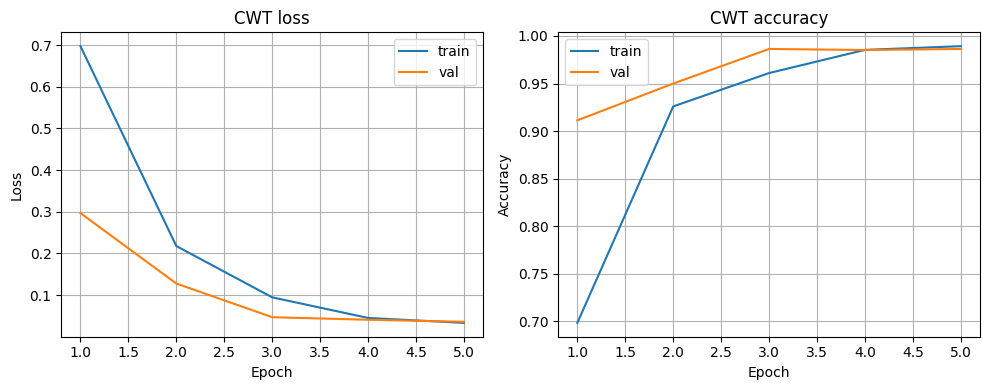

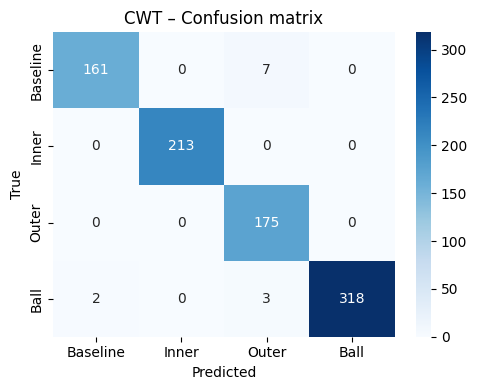


CWT classification report:

              precision    recall  f1-score   support

    Baseline       0.99      0.96      0.97       168
       Inner       1.00      1.00      1.00       213
       Outer       0.95      1.00      0.97       175
        Ball       1.00      0.98      0.99       323

    accuracy                           0.99       879
   macro avg       0.98      0.99      0.98       879
weighted avg       0.99      0.99      0.99       879



In [5]:
# ============================================================
# 5. Train + save CWT model
# ============================================================
cwt_model, cwt_history = train_model_for_rep(
    rep_name="CWT",
    num_epochs=5,   # same epochs for fair comparison
    lr=1e-3,
    in_channels=3,
    batch_size=32
)

torch.save(cwt_model.state_dict(), MODELS_ROOT / "CNN_CWT.pth")
